**Deep Learning-based hotel cancellation prediction system**

Deep Learning Final Project

**Students:** Dasmeet Makhija, Ghazal Koobchi, Hanneloreng Escudero

Introduction: In this project, we'll build a model to predict hotel cancellations with a binary classifier.

In [ ]:
# Setup plotting
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc(
    'axes',
    labelweight='bold',
    labelsize='large',
    titleweight='bold',
    titlesize=18,
    titlepad=10
)

plt.rc('animation', html='html5')

First, load the Hotel Cancellations dataset.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

hotel = pd.read_csv('hotel.csv.zip')

X = hotel.copy()
y = X.pop('is_canceled')

X['arrival_date_month'] = \
    X['arrival_date_month'].map(
        {'January':1, 'February': 2, 'March':3,
         'April':4, 'May':5, 'June':6, 'July':7,
         'August':8, 'September':9, 'October':10,
         'November':11, 'December':12}
    )

features_num = [
    "lead_time", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights",
    "stays_in_week_nights", "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "required_car_parking_spaces",
    "total_of_special_requests", "adr",
]
features_cat = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type",
]

transformer_num = make_pipeline(
    SimpleImputer(strategy="constant"), # there are a few missing values
    StandardScaler(),
)
transformer_cat = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="NA"),
    OneHotEncoder(handle_unknown='ignore'),
)

preprocessor = make_column_transformer(
    (transformer_num, features_num),
    (transformer_cat, features_cat),
)

# stratify - make sure classes are evenlly represented across splits
X_train, X_valid, y_train, y_valid = \
    train_test_split(X, y, stratify=y, train_size=0.75)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

input_shape = [X_train.shape[1]]

1. Define Model:
The model we'll use this time will have both batch normalization and dropout layers. To ease reading we've broken the diagram into blocks, but you can define it layer by layer as usual. Define a model with an architecture given by this diagram: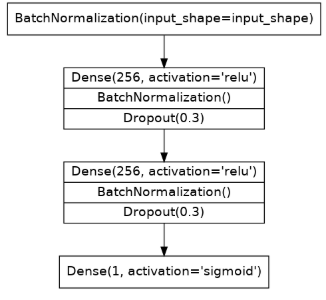

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


# Define model
model = keras.Sequential([

    # Input normalization
    layers.BatchNormalization(input_shape=input_shape),

    # First hidden block
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Second hidden block
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    # Output layer
    layers.Dense(1, activation='sigmoid'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**2. Add Optimizer, Loss, and Metric:**
Now we compile the model with the Adam optimizer and binary versions of the cross-entropy loss and accuracy metric

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

Finally, we run this cell to train the model and view the learning curves. It may run for around 60 to 70 epochs.

Epoch 1/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - binary_accuracy: 0.7740 - loss: 0.4767 - val_binary_accuracy: 0.8077 - val_loss: 0.4337
Epoch 2/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - binary_accuracy: 0.8023 - loss: 0.4208 - val_binary_accuracy: 0.8134 - val_loss: 0.4036
Epoch 3/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - binary_accuracy: 0.8094 - loss: 0.4075 - val_binary_accuracy: 0.8163 - val_loss: 0.3955
Epoch 4/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - binary_accuracy: 0.8135 - loss: 0.4002 - val_binary_accuracy: 0.8190 - val_loss: 0.3929
Epoch 5/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - binary_accuracy: 0.8151 - loss: 0.3950 - val_binary_accuracy: 0.8203 - val_loss: 0.3908
Epoch 6/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - binary_accuracy: 0.8174 - loss: 0.3910 - val_binary_accuracy: 0.8243 - val_loss: 0.3881
Epoch 7/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - binary_accuracy: 0.8201 - loss: 0.3871 - val_binary_accuracy: 0.8245 - val_los

<Axes: title={'center': 'Accuracy'}>

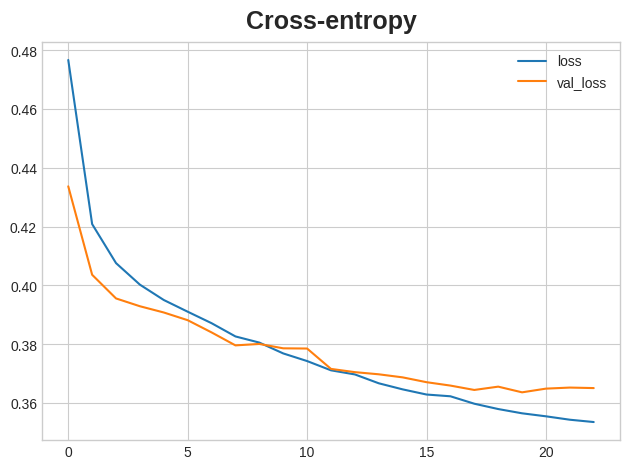

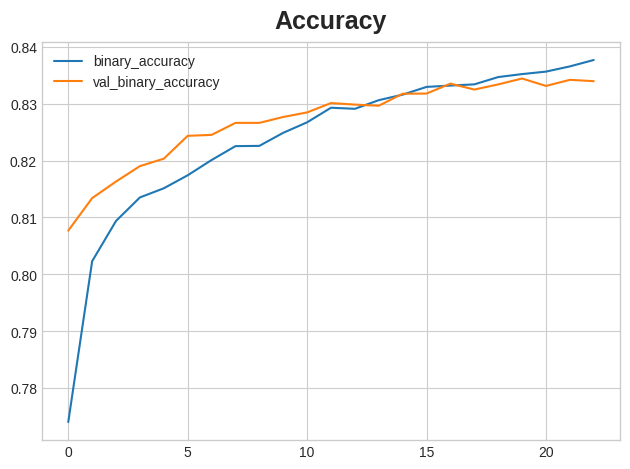

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Accuracy")

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Predict probabilities
y_pred_prob = model.predict(X_valid)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_valid, y_pred))

**3.  Train and Evaluate:**
Though we can see the training loss continuing to fall, the early stopping callback prevented any overfitting. Moreover, the accuracy rose at the same rate as the cross-entropy fell, so it appears that minimizing cross-entropy was a good stand-in. All in all, it looks like this training was a success!

**4. Conclusion: **Epoch no. 23/200 was the most accurate one with binary_accuracy: 0.8377, loss: 0.3535, val_binary_accuracy: 0.8340, and val_loss: 0.3650